# VQC Based on IQC and IQC:AIL

## Imports

In [1]:
import qiskit
from qiskit_machine_learning.algorithms import VQC
from qiskit.circuit import QuantumCircuit,Parameter
from qiskit.compiler import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, visualize_transition, plot_bloch_vector
from qiskit.circuit.library import UnitaryGate,Initialize
from qiskit.quantum_info import Statevector,partial_trace, DensityMatrix

import pennylane as qml
from pennylane import numpy as pnp
import qutip
from toqito import state_props

import numpy as np
from scipy.linalg import expm as expMatrix
from sympy.physics.quantum.dagger import Dagger
import math

from sklearn.model_selection import StratifiedKFold,train_test_split
from sklearn.datasets import make_blobs
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn import preprocessing
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, make_scorer, roc_auc_score, classification_report

from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pdflatex

import pandas as pd


## Base de Dados

In [2]:
#Parâmetros
RANDOM_SEED = 42
N_SAMPLES = 300
N_FEATURES = 4
N_CENTERS = 5
N_PRINTINGS = N_SAMPLES//10
N_SHOTS=2048
LEARNING_RATE = 0.01
RESPONSE_METHOD = "predict"
results = []
N_QUBITS=math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
weights=np.full(N_FEATURES,1)
QUBITS=[i for i in range(N_QUBITS)]

### IQC

In [3]:
#Gerando o dataset
def generate_blobs(normalize_col=False, normalize_lin=False):
  X, y = make_blobs(n_samples=N_SAMPLES, n_features=N_FEATURES, centers=N_CENTERS, random_state=RANDOM_SEED,cluster_std=0.7)

  if normalize_col:
    scaler = MinMaxScaler()
    scaler.fit(X)
    X = scaler.transform(X)
    X = X - 1
  if normalize_lin:
    X = preprocessing.normalize(X,axis=1,norm='l2')


  return X, y

X_blobs,y_blobs=generate_blobs(normalize_col=True)


### IQC:AIL

In [4]:
#Gerando o dataset
def generate_blobs(normalize_col=False, normalize_lin=False):
  X, y = make_blobs(n_samples=N_SAMPLES, n_features=N_FEATURES, centers=N_CENTERS, random_state=RANDOM_SEED,cluster_std=0.7)

  if normalize_col:
    scaler = MinMaxScaler()
    scaler.fit(X)
    X = scaler.transform(X)
  if normalize_lin:
    X = preprocessing.normalize(X,axis=1,norm='l2')


  return X, y

X_blobs,y_blobs=generate_blobs(normalize_lin=True)

### Boxplot

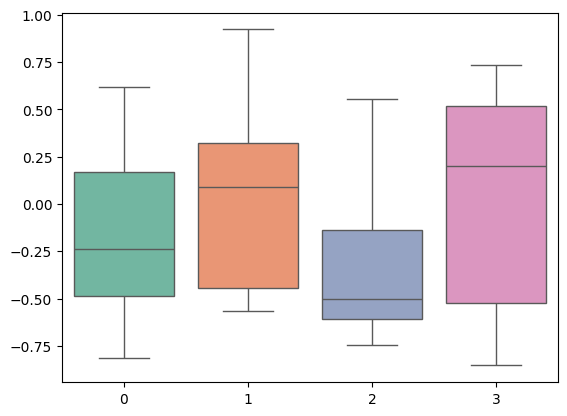

In [5]:
fig, ax = plt.subplots()
sns.boxplot(X_blobs, palette="Set2",ax=ax)
plt.savefig('boxplot_blobs.svg')

## Tratamento do Dataset

### IQC

In [ ]:
def normalize_iqc(data, normalize_col=False, normalize_lin=False):
    if normalize_lin:
        data = preprocessing.normalize(data,axis=1,norm='l2') #Normalize the line between [0,1]
    return data
    
X_blobs_iqc_coluna=normalize_iqc(X_blobs, normalize_col=True, normalize_lin=False)
X_blobs_iqc_linha=normalize_iqc(X_blobs, normalize_col=False, normalize_lin=True)

### IQC:AIL

In [6]:
def normalize_iqc_ail(data, normalize_col=False, normalize_lin=False):
    if normalize_col:
        scaler = MinMaxScaler() #Normalize the column between [0,1]
        scaler.fit(data)
        data = scaler.transform(data)
        '''
        Perceba que normalizando apenas a coluna, podemos ter amplitudes dos estados em que a norma do estado não fosse igual a 1. Para resolvermos isso, devemos
        normalizar as linhas entre si

        '''
        data = preprocessing.normalize(data,axis=1,norm='l2')
    if normalize_lin:
        data = preprocessing.normalize(data,axis=1,norm='l2') #Normalize the line between [0,1]
    return data
    
X_blobs_iqc_ail_coluna=normalize_iqc_ail(X_blobs, normalize_col=True, normalize_lin=False)
X_blobs_iqc_ail_linha=normalize_iqc_ail(X_blobs,normalize_col=False,normalize_lin=True)

## Estratificando o dataset

In [6]:
#Gerando os datasets de treino e teste
X_train_coluna, X_test_coluna, y_train_coluna, y_test_coluna=train_test_split(X_blobs_iqc_ail_coluna,y_blobs,test_size=0.3,train_size=0.7)

X_train_linha, X_test_linha, y_train_linha, y_test_linha=train_test_split(X_blobs_iqc_ail_linha,y_blobs,test_size=0.3,train_size=0.7)

In [7]:
#Plotando os dados em que N_features==2
if N_FEATURES==2:
    plt.figure(figsize=(8, 8))
    plt.title("Exemplo simples de base de dados Moons", fontsize="small")
    plt.scatter(X_blobs[:, 0], X_blobs[:, 1], marker="o", s=25, c=y_blobs, edgecolor="k")
    plt.savefig("Dataset_blobs.png", dpi=1500)
    plt.show()

## Quantum Circuit

Não geraremos imagens ainda

### Circuito IQC em Pennylane

Ainda em construção

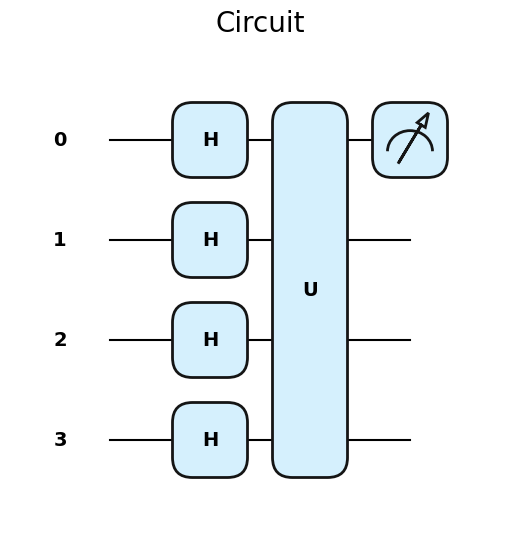

In [25]:
N_atributos=N_FEATURES 
'''
Numero de atributos do vetor a ser classificado. Adicionamos mais 1 ao numero obtido antes(pois temos o qubit alvo)
'''
#Escolhendo uma linha aleatória de X para podermos debugar
lista=[i for i in range(len(X_blobs))]
j=int(np.random.choice(lista))

w=weights

#x=np.random.rand(N_atributos)
#w=np.random.rand(N_atributos)

N_qubits=math.ceil(np.log2(N_atributos)+1) #Nqubits do circuito

#Podíamos inicializar assim pra facilitar as contas
'''x=np.random.rand(2**N_atributos)
w=np.random.rand(2**N_atributos)'''

#Montando os sigmas

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z



X_blobs_new=list(X_blobs[j])
if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
    for k in range(2**(N_qubits-1) - N_atributos):
        X_blobs_new.append(0)
        w=np.append(w,0)
    sigmaE=np.diag(X_blobs_new)*w.T
else:
    sigmaE=np.diag(X_blobs_new)*w.T

#Operador Unitário
U=pnp.matrix(expMatrix(1j*pnp.kron(sigmaQ,sigmaE)))
#U=np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]])

#tem que inicializar o device
qubits=[i for i in range(N_qubits)]
dev = qml.device("default.qubit", wires = qubits)

@qml.qnode(dev)
def circuit():

    #https://docs.pennylane.ai/en/stable/introduction/operations.html lista dos operadores do pennylane
    #colocar as portas aq
    for i in range(N_qubits):
        qml.Hadamard(wires=[i])
    qml.QubitUnitary(U, wires=qubits)

    return qml.density_matrix([0]) #Retorna a matriz reduzida do qubit alvo

state=circuit
#print(state())
qml.drawer.use_style('pennylane')
fig, ax = qml.draw_mpl(circuit)()
ax.set_aspect('equal')
fig.set_figwidth(20)
plt.title("Circuit",size = 20)
plt.show()

In [26]:
print(U.shape)

(16, 16)


### Circuito IQC em Qiskit

X[154]: [7.941498713241802, -6.502277122862783, -7.431368275505305, -6.816245451848195] ; w: [1 1 1 1] 

sigmaE
[[ 7.94149871  0.          0.          0.        ]
 [ 0.         -6.50227712  0.          0.        ]
 [ 0.          0.         -7.43136828  0.        ]
 [ 0.          0.          0.         -6.81624545]]


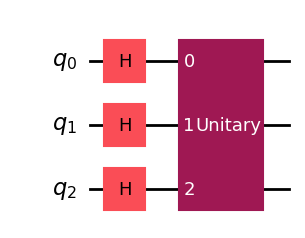

In [13]:
# Criando o circuito com um vetor qualquer do dataset para exemplificar

N_atributos=N_FEATURES 
'''
Numero de atributos do vetor a ser classificado. Adicionamos mais 1 ao numero obtido antes(pois temos o qubit alvo)
'''
#Escolhendo uma linha aleatória de X para podermos debugar
lista=[i for i in range(len(X_blobs))]
j=int(np.random.choice(lista))

w=weights

#x=np.random.rand(N_atributos)
#w=np.random.rand(N_atributos)

N_qubits=N_QUBITS

#Podíamos inicializar assim pra facilitar as contas
'''x=np.random.rand(2**N_atributos)
w=np.random.rand(2**N_atributos)'''

# IQC

qc = QuantumCircuit(N_qubits)
qc.h(0) # Inicializaçao do estado inicial. Poderia ser qualquer estado.
qc.h(range(1,N_qubits))



#Montando os sigmas

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z



X_blobs_new=list(X_blobs[j])
if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
    for k in range(2**(N_qubits-1) - N_atributos):
        X_blobs_new.append(0)
        w=np.append(w,0)
    sigmaE=np.diag(X_blobs_new)*w.T
else:
    sigmaE=np.diag(X_blobs_new)*w.T

#Debugando
print(f'X[{j}]:', X_blobs_new, '; w:', w,'\n')
print('sigmaE')
print(sigmaE)
#Operador Unitário
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

qubits=[i for i in range(N_qubits)]
# qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
qc.unitary(U,qubits)
qc.draw("mpl")

{'u3': 23, 'cx': 15}


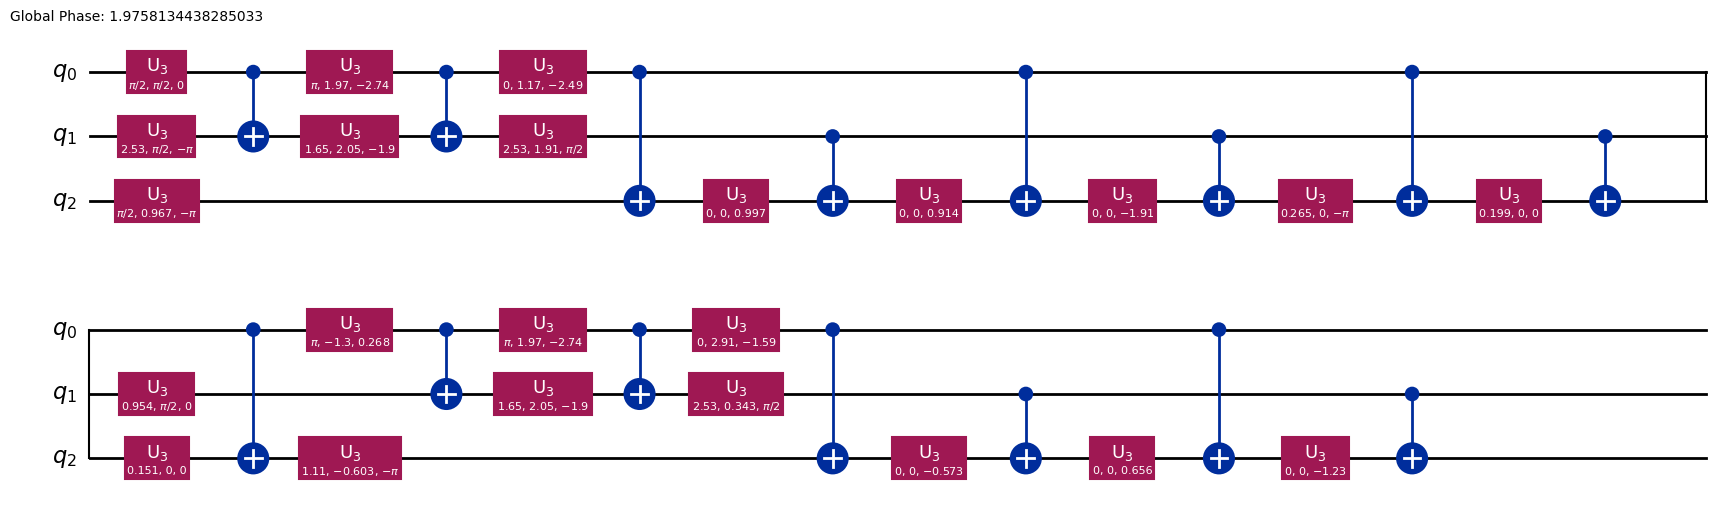

In [15]:
#Decompondo em portas U3 e CX
qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
print(dict(qc.count_ops()))
if dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50:
    display(qc.draw('mpl'))

#### Statevector e Matriz Densidade

Aqui vamos avaliar o estado depois da evolução 

##### Statevector

<IPython.core.display.Latex object>

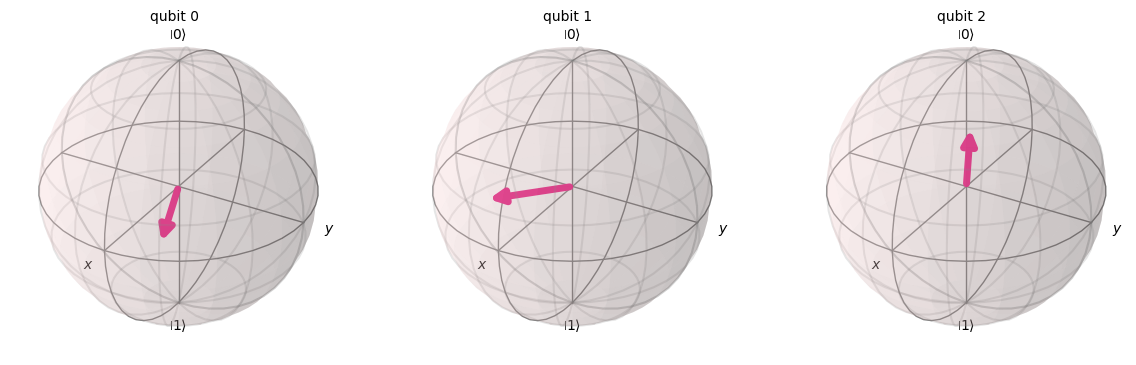

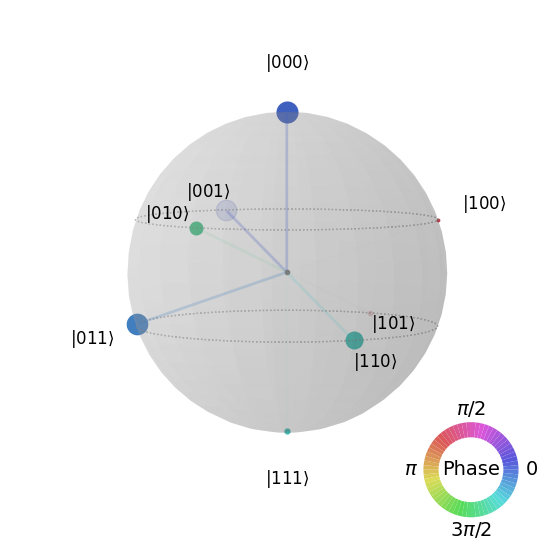

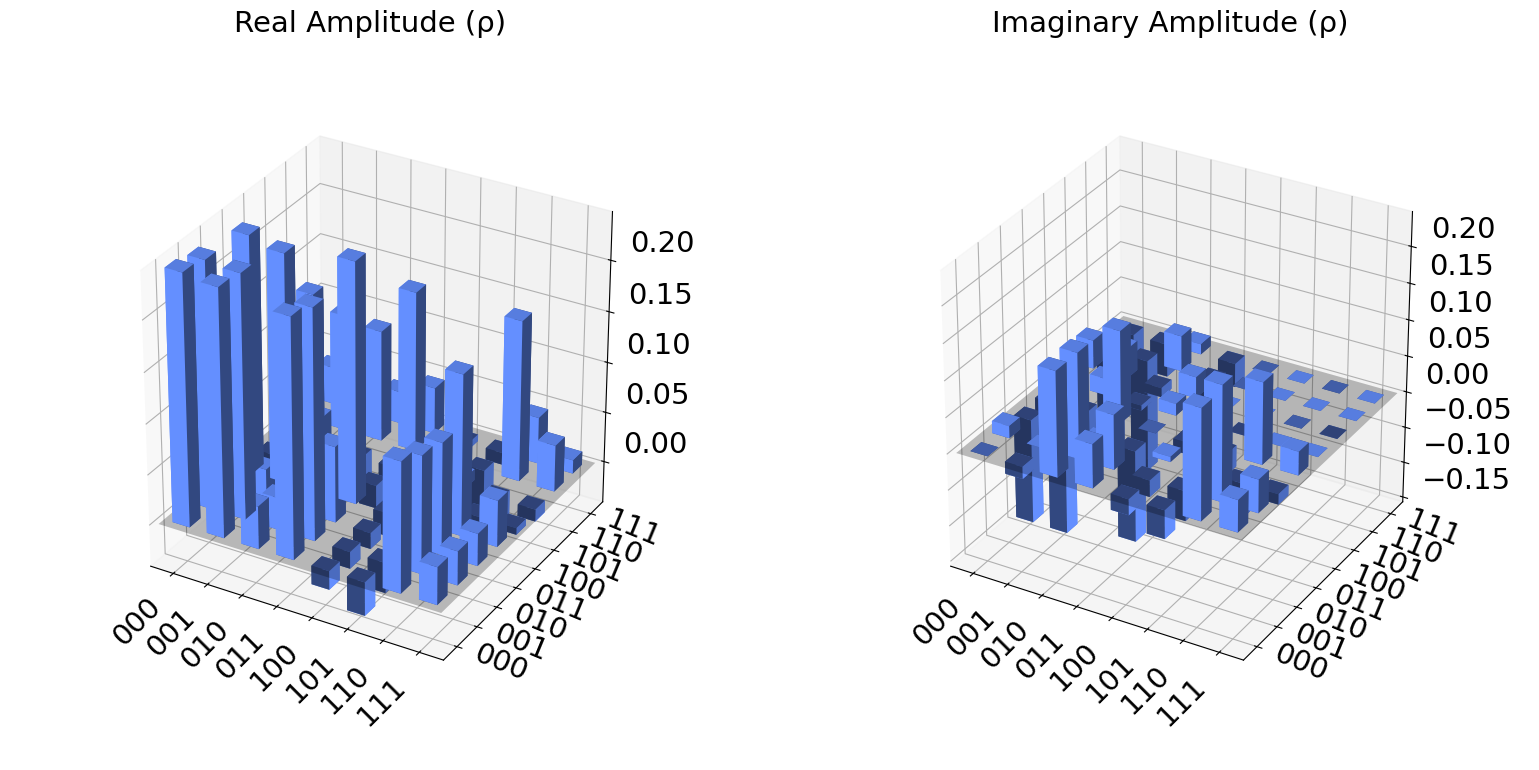

In [16]:
#Estado completo
sv = Statevector(qc)
'''
'mpl' is not a valid option for drawing Statevector objects. Please choose from:
            'text', 'latex', 'latex_source', 'qsphere', 'hinton',
            'bloch', 'city' or 'paulivec'
'''

display(sv.draw("latex")) #Plota o vetor de estado já em cada espaço de Hilbert
display(sv.draw("bloch")) #Plota o vetor de estado já em cada espaço de Hilbert
display(sv.draw("qsphere")) #Plota o vetor de estado em uma esfera que mapeia o espaço tensorial originado pelos espaços de Hilbert
display(sv.draw("city")) #Plota o histograma da matriz densidade SEM MEDÍ-LA


##### Partial Trace

Vamos traçar o sis. auxiliar

In [17]:
rho = partial_trace(sv,qubits[1:])
print(rho)

def blochvector(rho):
    x = np.trace(matriz_pauli_x@rho.data)
    y= np.trace(matriz_pauli_y@rho.data)
    z = np.trace(matriz_pauli_z@rho.data)
    return [x,y,z]
blochvector(rho)


DensityMatrix([[0.5       +0.j        , 0.36937088-0.14291238j],
               [0.36937088+0.14291238j, 0.5       +0.j        ]],
              dims=(2,))


[(0.7387417514355655+0j), (0.2858247615530393+0j), (1.1102230246251565e-16+0j)]

##### Ponto na Casca da superfície da Esfera de Bloch

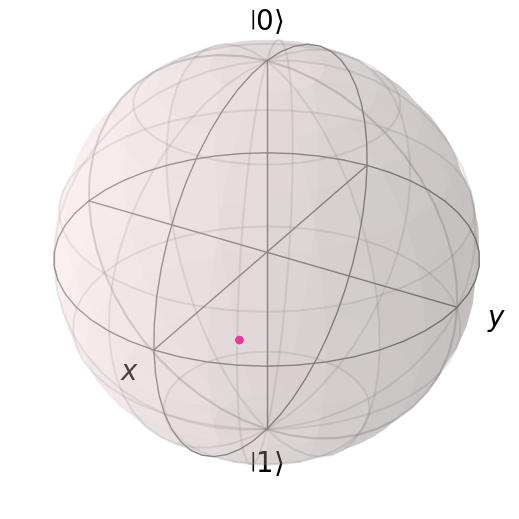

In [18]:
b = qutip.Bloch()
b.point_default_color=['deeppink']
b.add_points(blochvector(rho))

b.render()
b.show()

##### Matriz Densidade

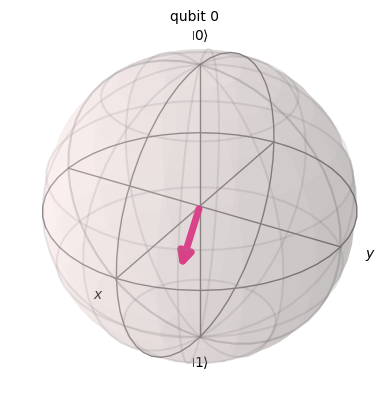

In [19]:
#Ao traçar fora o ambiente
rho_res = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:])
#rho_res = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:]).data

display(rho_res.draw('bloch'))

Como podemos observar, conseguimos marcar o ponto, na superfície da esfera, ao qual o autovetor do SISTEMA pertence. E se fizermos isso durante todo o código?

##### Negatividade

In [20]:
Negativity = (np.linalg.norm(rho_res)-1)/2

#### Executando o Circuito

{'011': 236, '001': 260, '110': 176, '000': 237, '010': 93, '101': 8, '111': 10, '100': 4}


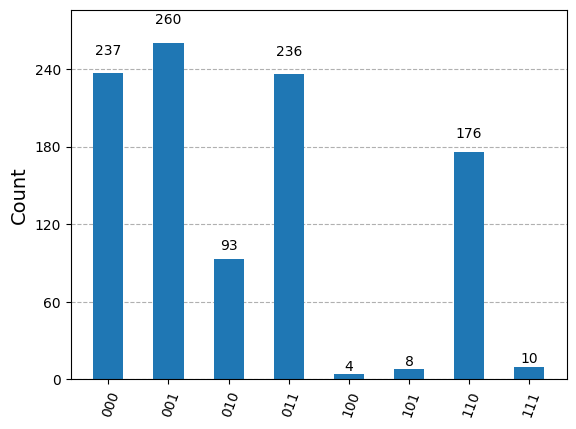

In [21]:
#Executar o circuito
def run_qasm_counts(circ, shots=1024):
  qc.measure_all()
  qasm_simulator = Aer.get_backend("qasm_simulator")
  job = qasm_simulator.run(qc, shots=shots)
  result = job.result()
  return result.get_counts()

counts = run_qasm_counts(qc)
print(counts)
plot_histogram(counts)

## Função que junta tudo até agora

### IQC

In [11]:
def blochvector(rho_cog):
    x_bloch = np.trace(matriz_pauli_x@rho_cog.data)
    y_bloch = np.trace(matriz_pauli_y@rho_cog.data)
    z_bloch = np.trace(matriz_pauli_z@rho_cog.data)
    return [x_bloch,y_bloch,z_bloch]
    
#Executar o circuito
def run_qasm_counts(circ, shots=N_SHOTS):
    qc.measure_all()
    qasm_simulator = Aer.get_backend("qasm_simulator")
    job = qasm_simulator.run(qc, shots=shots)
    result = job.result()
    return result.get_counts()

def cirq_iqc(data,contador,w=weights,qubits=QUBITS, N_qubits=N_QUBITS,N_atributos=N_FEATURES,printar_cirq=False):

    X_blobs_new=list(data)
    if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
        for k in range(2**(N_qubits-1) - N_atributos):
            w=np.append(w,0)
            X_blobs_new=np.append(X_blobs_new,0)
        sigmaE=np.diag(X_blobs_new)*w.T
    else:
        sigmaE=np.diag(X_blobs_new)*w.T
    
    #Podíamos inicializar assim pra facilitar as contas
    '''x=np.random.rand(2**N_atributos)
    w=np.random.rand(2**N_atributos)'''

    # IQC:AIL

    qc = QuantumCircuit(N_qubits)

    qc.initialize(X_blobs_new, range(1,N_qubits))# Inicializaçao do estado inicial. Poderia ser qualquer estado.
    qc.h(0)
    qc.h(range(1,N_qubits))



    #Montando os sigmas

    matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
    matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
    matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

    sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

    

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

    # qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
    qc.unitary(U,qubits)
    if contador==0:
        qc.draw("mpl", filename=f'./mpl_complete_U_blobs.png')
    if printar_cirq==True:
        display(qc.draw('mpl')) #display(qc.draw("mpl", filename='./mpl_original.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    #qc.decompose().draw(output="mpl", style="clifford")
    qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
    if dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50 and contador%N_PRINTINGS==0:
        qc.draw("mpl", filename=f'./mpl_transpiled{contador}_blobs.png')

    if printar_cirq==True and dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50:
        print(dict(qc.count_ops()))
        display(qc.draw('mpl')) #display(qc.draw('mpl', filename='./mpl_transpile.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    # Mostrando o vetor de estado 
    sv = Statevector(qc)
    if contador%N_PRINTINGS==0:
        sv.draw("city", filename=f'./state_vector_city{contador}_blobs.png')
        sv.draw("bloch", filename=f'./state_vector_bloch{contador}_blobs.png')
        sv.draw("qsphere", filename=f'./state_vector_qsphere{contador}_blobs.png')
    if printar_cirq==True:
        display(sv.draw("latex"))

    rho_cog = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:])
    if printar_cirq==True:
        print(rho_cog)

    rho_cog_00=rho_cog.data[0,0]
    rho_cog_11=rho_cog.data[1,1]

    if (rho_cog_00 >= rho_cog_11):
        z = 0
    else:
        z = 1
    
    
    counts = run_qasm_counts(qc)
    if contador%N_PRINTINGS==0:
        plot_histogram(counts,filename=f'./histogram_plot_{contador}_blobs.png')
    


    return [z,blochvector(rho_cog)]

### IQC:AIL

In [7]:
def blochvector(rho_cog):
    x_bloch = np.trace(matriz_pauli_x@rho_cog.data)
    y_bloch = np.trace(matriz_pauli_y@rho_cog.data)
    z_bloch = np.trace(matriz_pauli_z@rho_cog.data)
    return [x_bloch,y_bloch,z_bloch]
    
#Executar o circuito
def run_qasm_counts(circ, shots=N_SHOTS):
    qc.measure_all()
    qasm_simulator = Aer.get_backend("qasm_simulator")
    job = qasm_simulator.run(qc, shots=shots)
    result = job.result()
    return result.get_counts()

def cirq_iqc_ail(data,contador,w=weights,qubits=QUBITS, N_qubits=N_QUBITS,N_atributos=N_FEATURES,printar_cirq=False):

    X_blobs_new=list(data)
    if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
        for k in range(2**(N_qubits-1) - N_atributos):
            w=np.append(w,0)
            X_blobs_new=np.append(X_blobs_new,0)
        sigmaE=np.diag(w)
    else:
        sigmaE=np.diag(w)
    
    #Podíamos inicializar assim pra facilitar as contas
    '''x=np.random.rand(2**N_atributos)
    w=np.random.rand(2**N_atributos)'''

    # IQC:AIL

    qc = QuantumCircuit(N_qubits)

    qc.initialize(X_blobs_new, range(1,N_qubits))# Inicializaçao do estado inicial. Poderia ser qualquer estado.
    qc.h(0)
    qc.h(range(1,N_qubits))



    #Montando os sigmas

    matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
    matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
    matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

    sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

    

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

    # qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
    qc.unitary(U,qubits)
    if contador==0:
        qc.draw("mpl", filename=f'./mpl_complete_U_blobs.png')
    if printar_cirq==True:
        display(qc.draw('mpl')) #display(qc.draw("mpl", filename='./mpl_original.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    #qc.decompose().draw(output="mpl", style="clifford")
    qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
    if dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50 and contador%N_PRINTINGS==0:
        qc.draw("mpl", filename=f'./mpl_transpiled{contador}_blobs.png')

    if printar_cirq==True and dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50:
        print(dict(qc.count_ops()))
        display(qc.draw('mpl')) #display(qc.draw('mpl', filename='./mpl_transpile.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    # Mostrando o vetor de estado 
    sv = Statevector(qc)
    if contador%N_PRINTINGS==0:
        sv.draw("city", filename=f'./state_vector_city{contador}_blobs.png')
        sv.draw("bloch", filename=f'./state_vector_bloch{contador}_blobs.png')
        sv.draw("qsphere", filename=f'./state_vector_qsphere{contador}_blobs.png')
    if printar_cirq==True:
        display(sv.draw("latex"))

    rho_cog = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:])
    if printar_cirq==True:
        print(rho_cog)

    rho_cog_00=rho_cog.data[0,0]
    rho_cog_11=rho_cog.data[1,1]

    if (rho_cog_00 >= rho_cog_11):
        z = 0
    else:
        z = 1
    
    
    counts = run_qasm_counts(qc)
    if contador%N_PRINTINGS==0:
        plot_histogram(counts,filename=f'./histogram_plot_{contador}_blobs.png')
    


    return [z,blochvector(rho_cog)]

## Esfera de Bloch do Circuito

### IQC

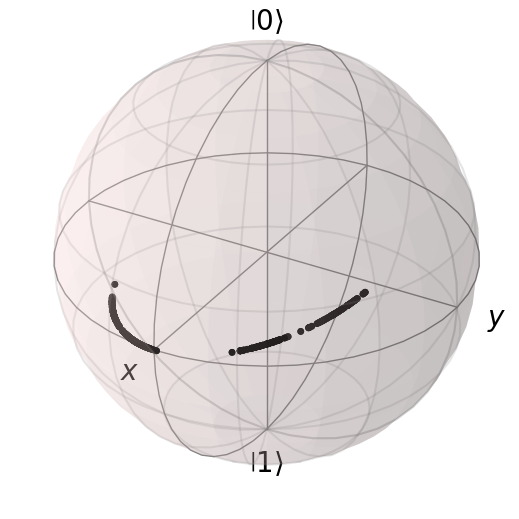

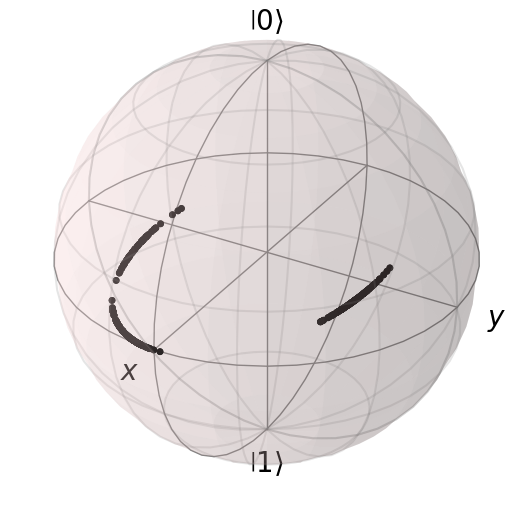

In [13]:
def esfera_bloch_IQC(X,counter,norma):
    point_states=[]
    for k in range(0,N_SAMPLES):
        point_states.append(cirq_iqc(X[k],k,N_FEATURES))

    b = qutip.Bloch()
    b.point_default_color=['k']
    b.point_marker=['o']
    b.point_size=[15, 15, 15, 15]
    for k in range(len(point_states)):
        b.add_points(point_states[k])
    b.render()
    b.show()

    bb = b.fig
    bb.savefig(f'Bloch_geral_blobs{counter}_IQC_AIL_{norma}.png')

esfera_bloch_IQC(X_blobs_iqc_coluna,1,'coluna')
esfera_bloch_IQC(X_blobs_iqc_linha,1,'linha')

### IQC:AIL

In [21]:
def esfera_bloch_IQC_AIL(X,counter,norma,weights=weights,printar_esf=False):
    point_states=[]
    k_tuple=[]
    z_updt=[]
    for k in range(0,N_SAMPLES):
        k_tuple.append(cirq_iqc_ail(X[k],k,w=weights))
        z_updt.append(k_tuple[0][0])
        point_states.append(k_tuple[0][1])
        k_tuple=[]

    b = qutip.Bloch()
    b.point_default_color=['k']
    b.point_marker=['o']
    b.point_size=[15, 15, 15, 15]
    for k in range(len(point_states)):
        b.add_points(point_states[k])
    b.render()
    if printar_esf==True:
        b.show()

    bb = b.fig
    bb.savefig(f'Bloch_geral_blobs{counter}_IQC_AIL_{norma}.png')
    return z_updt

z1=esfera_bloch_IQC_AIL(X_blobs_iqc_ail_coluna,1,'coluna')
z2=esfera_bloch_IQC_AIL(X_blobs_iqc_ail_linha,1,'linha')

In [23]:
z2

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


## Treinamento

In [ ]:
def get_stratified_kfold(k_folds=10, random_seed=42):
    return StratifiedKFold(n_splits=k_folds, random_state=random_seed, shuffle=True)

def print_metrics(scores, f1scores):
    print("Scores:", scores)
    print("Best score:", np.max(scores))
    print("F1-Scores:", f1scores)
    print("Max F1-Score:", np.max(f1scores))
    print("Avg score:", np.mean(scores))
    print("Avg F1-Score:", np.mean(f1scores))

def execute_training_test_k_fold(
                X, 
                y, 
                k_folds=10,
                random_seed = 42, 
                classifier_function=None, 
                dic_classifier_params={},
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params={},
                print_each_fold_metric=False,
                print_avg_metric=True):
    """
        Executes ICQ classifier against an dataset using classifier_function as classifier (see /helpers/icq_executions.py for more info).
        As for datasets, we need it to return a pair X, y. See database_helpers for examples
    """

    if "classical_classifier" in dic_training_params:
        classifier = dic_training_params["classifier"] 
        classical_classifier = True
    else:
        classical_classifier = False
        
    # Creating K-Fold to use
    skf = get_stratified_kfold(k_folds=k_folds, random_seed=random_seed)

    scores = []
    f1scores = []

    negativities = [[]]
    entropies = [[]]

    # Training the classifier itself
    for i, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train = X[train_index]
        X_test = X[test_index]

        y_train = y[train_index]
        y_test = y[test_index]

        if classical_classifier: 
            clf = one_vs_classifier(classifier).fit(X_train, y_train)  
        else:
            clf = one_vs_classifier(
                    iqc_ail_clf.fit(X_train, y_train))

        score = clf.score(X_test, y_test)
        f1score = f1_score(clf.predict(X_test), y_test, average='macro')

        if not(classical_classifier):
            while len(negativities) < len(clf.estimators_):
                negativities.append([])
                entropies.append([])
            
            index = 0
            for estimator in clf.estimators_:
                # negativities variable will look like this:
                # negativities[0] = all folds mean(negativity) for class 0 - which means that len(negativities[0]) = k_folds;
                # so if we want to take average negativity of class 0 for all folds, we need to take mean(negativities[0]).
                # Same goes for entropies
                negativities[index].append(estimator.negativity_)
                entropies[index].append(estimator.entropy_)
                index = index + 1

        scores.append(score)
        f1scores.append(f1score)

        if print_each_fold_metric:
            y_pred = clf.predict(X_test)
            print("K-Fold #" + str(i))

            # Since negativities and Entropies gets the mean per fold, the info we want is in the last one.
            print("Mean negativities for all classes:", [neg[-1] for neg in negativities])
            print("Mean entropies for all classes:", [entrs[-1] for entrs in entropies])

            # Actual report
            print(classification_report(y_test, y_pred))
            print("-------------------------------------------------------------------------------------------------------------------")
    
    if print_avg_metric:
        print("AVG: Scores =", np.mean(scores), 
              "F1-Scores =", np.mean(f1scores), 
              "Negativity =", [np.mean([neg[i] for neg in negativities]) for i in range(len(set(y)))], 
              "Entropy =", [np.mean([neg[i] for neg in entropies]) for i in range(len(set(y)))])

    output_dict = {}
    output_dict["negativities"] = negativities
    output_dict["entropies"] = entropies
    return scores, f1scores, output_dict

def print_score(scores_list):
    print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
    print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
    print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

    print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])
    print()
    print()
    print(scores_list)
     

def print_f1score(f1scores_list):
    print("Media F1Score dos N K-Fold", np.mean([np.mean(i) for i in f1scores_list]))
    print("Maior F1Score dos K-Fold", max([np.mean(i) for i in f1scores_list]))
    print("Maior F1Score dos K-Fold", min([np.mean(i) for i in f1scores_list]))

    print("Media F1Score dos K-Fold", [np.mean(i) for i in f1scores_list])
    print()
    print()
    print(f1scores_list)

def update_weights(weights, y, z, x, p, n):
  """
    Updates the weights. Equation #34 in the Article.
    
    z is the expected classification [0, 1];
    y is the actual classification [0, 1];
    x is the attribute vector;
    p is the probability of the class 1 (0, 1), powered to 2 (p²);
    n is the learning rate.
  """
  # Eq 33
  loss_derivative_on_weight = (1-p)*x

  # Eq 34
  weights = weights-n*(z-y)*loss_derivative_on_weight
  weights[np.isnan(weights)] = 0
  return weights


In [ ]:
scores = cross_val_score(clf, X, y, cv=10, scoring='accuracy')

## GPT

In [16]:
#Executar o circuito
def run_qasm_counts(qc, shots=N_SHOTS):
    qc.measure_all()
    qasm_simulator = Aer.get_backend("qasm_simulator")
    job = qasm_simulator.run(qc, shots=shots)
    result = job.result()
    return result.get_counts()

def update_weights(weights, y, z, x, p, n):
  """
    Updates the weights. Equation #34 in the Article.
    
    z is the expected classification [0, 1];
    y is the actual classification [0, 1];
    x is the attribute vector;
    p is the probability of the class 1 (0, 1), powered to 2 (p²);
    n is the learning rate.
  """
  # Eq 33
  loss_derivative_on_weight = (1-p)*x

  # Eq 34
  weights = weights-n*(z-y)*loss_derivative_on_weight
  weights[np.isnan(weights)] = 0
  return weights

def cirq_iqc_ail_clf(data,contador,iteration,w=weights,qubits=QUBITS, N_qubits=N_QUBITS,N_atributos=N_FEATURES,printar_cirq=False):

    X_blobs_new=list(data)
    if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
        for k in range(2**(N_qubits-1) - N_atributos):
            w=np.append(w,0)
            X_blobs_new=np.append(X_blobs_new,0)
        sigmaE=np.diag(w)
    else:
        sigmaE=np.diag(w)
    

    # IQC:AIL

    qc = QuantumCircuit(N_qubits)

    qc.initialize(X_blobs_new, range(1,N_qubits))# Inicializaçao do estado inicial. Poderia ser qualquer estado.
    qc.h(0)
    qc.h(range(1,N_qubits))



    #Montando os sigmas

    matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
    matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
    matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

    sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

    

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

    # qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
    qc.unitary(U,qubits)
    if contador==0:
        qc.draw("mpl", filename=f'./mpl_complete_U_blobs{iteration}.png')

    #qc.decompose().draw(output="mpl", style="clifford")
    qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
    if contador==0:
        qc.draw("mpl", filename=f'./mpl_transpiled{iteration}_blobs.png')

    # Mostrando o vetor de estado 
    sv = Statevector(qc)
    if contador==0:
        sv.draw("city", filename=f'./state_vector_city{iteration}_blobs.png')
        sv.draw("bloch", filename=f'./state_vector_bloch{iteration}_blobs.png')
        sv.draw("qsphere", filename=f'./state_vector_qsphere{iteration}_blobs.png')
    if printar_cirq==True:
        display(sv.draw("latex"))

    rho_cog = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:])
    if printar_cirq==True:
        print(rho_cog)

    rho_cog_00=rho_cog.data[0,0]
    rho_cog_11=rho_cog.data[1,1]

    if (rho_cog_00 >= rho_cog_11):
        z = 0
    else:
        z = 1
    
    
    counts = run_qasm_counts(qc)
    if contador%N_PRINTINGS==0:
        plot_histogram(counts,filename=f'./histogram_plot_{contador}_blobs.png')
    


    return [z,rho_cog_11]

def iqc_ail_clf(X,weights=weights):
    z,_=cirq_iqc_ail(X,k,w=weights)
    weights = update_weights(weights,)

In [20]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def train_10_fold(data, labels, n_folds=10, learning_rate=0.01, n_iter=100, print_progress=False):
    """
    Realiza o treinamento 10-fold usando o classificador IQC:AIL.

    Args:
    - data: conjunto de dados (ex.: numpy array)
    - labels: rótulos correspondentes aos dados
    - n_folds: número de folds para a validação cruzada (padrão 10)
    - learning_rate: taxa de aprendizado para a atualização dos pesos
    - n_iter: número de iterações para cada fold
    - print_progress: se True, imprime o progresso e resultados intermediários

    Returns:
    - médias das métricas (acurácia, precisão, recall e F1) para os folds
    """
    kf = KFold(n_splits=n_folds)
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1_scores = []

    # Inicializar pesos (você pode ajustar o tamanho conforme necessário)
    weights = np.random.rand(data.shape[1])
    if print_progress:
        print(weights)

    for fold, (train_index, test_index) in enumerate(kf.split(data)):
        if print_progress:
            print(f"Treinando fold {fold + 1} de {n_folds}...")

        # Dividir dados em treino e teste para este fold
        X_train, X_test = data[train_index], data[test_index]
        y_train, y_test = labels[train_index], labels[test_index]

        # Treinamento
        for iteration in range(n_iter):
            for i, x in enumerate(X_train):
                # Executa a função cirq_iqc_ail_clf para obter predição e probabilidade
                z, p = cirq_iqc_ail_clf(x, i, iteration, weights)
                y = y_train[i]

                # Atualiza os pesos
                weights = update_weights(weights, y, z, x, p, learning_rate)

        # Teste do fold atual
        y_pred = []
        for x in X_test:
            z, _ = cirq_iqc_ail_clf(x, contador=0, iteration=0, w=weights)
            y_pred.append(z)

        # Calcular métricas de avaliação
        fold_accuracy = accuracy_score(y_test, y_pred)
        fold_precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        fold_recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        fold_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)


        # Armazenar métricas para o fold
        fold_accuracies.append(fold_accuracy)
        fold_precisions.append(fold_precision)
        fold_recalls.append(fold_recall)
        fold_f1_scores.append(fold_f1)

        if print_progress:
            print(f"Fold {fold + 1} - Acurácia: {fold_accuracy:.4f}, Precisão: {fold_precision:.4f}, Recall: {fold_recall:.4f}, F1-score: {fold_f1:.4f}")

    # Calcular médias das métricas entre os folds
    avg_accuracy = np.mean(fold_accuracies)
    avg_precision = np.mean(fold_precisions)
    avg_recall = np.mean(fold_recalls)
    avg_f1_score = np.mean(fold_f1_scores)

    # Exibir resultados finais
    scores={
        
    }
    print(f"Média das métricas em {n_folds} folds:")
    print(f"Acurácia: {avg_accuracy:.4f}")
    print(f"Precisão: {avg_precision:.4f}")
    print(f"Recall: {avg_recall:.4f}")
    print(f"F1-score: {avg_f1_score:.4f}")

    return avg_accuracy, avg_precision, avg_recall, avg_f1_score


In [21]:
scores=dict(train_10_fold(X_blobs_iqc_ail_coluna, y_blobs, n_folds=10, learning_rate=0.01, n_iter=100, print_progress=True))

[0.19284748 0.00169412 0.23891085 0.81544722]
Treinando fold 1 de 10...
Fold 1 - Acurácia: 0.0000, Precisão: 0.0000, Recall: 0.0000, F1-score: 0.0000
Treinando fold 2 de 10...
Fold 2 - Acurácia: 0.0667, Precisão: 0.0296, Recall: 0.0667, F1-score: 0.0410
Treinando fold 3 de 10...
Fold 3 - Acurácia: 0.2000, Precisão: 0.0400, Recall: 0.2000, F1-score: 0.0667
Treinando fold 4 de 10...
Fold 4 - Acurácia: 0.1667, Precisão: 0.0362, Recall: 0.1667, F1-score: 0.0595
Treinando fold 5 de 10...
Fold 5 - Acurácia: 0.0000, Precisão: 0.0000, Recall: 0.0000, F1-score: 0.0000
Treinando fold 6 de 10...


KeyboardInterrupt: 

## Angle Embedding Qiskit

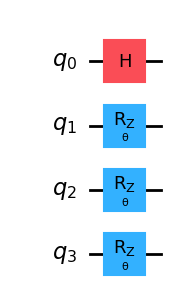

In [65]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

custom_circ = QuantumCircuit(N_qubits)
theta = Parameter("\u03B8")
custom_circ.h(0)
custom_circ.rz(theta, range(1,N_qubits))
custom_circ.draw('mpl')

## Amplitude Embedding Pennylane

In [16]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

N_atributos=N_FEATURES
lista=[i for i in range(len(X_blobs))]
j=int(np.random.choice(lista))

w=np.full(N_atributos,1)

#x=np.random.rand(N_atributos)
#w=np.random.rand(N_atributos)

N_qubits=math.ceil(np.log2(N_atributos)+1) #Nqubits do circuito

#Podíamos inicializar assim pra facilitar as contas
'''x=np.random.rand(2**N_atributos)
w=np.random.rand(2**N_atributos)'''

#Montando os sigmas

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z



X_blobs_new=list(X_blobs[j])
if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
    for k in range(2**(N_qubits-1) - N_atributos):
        X_blobs_new.append(0)
        w=np.append(w,0)
    sigmaE=np.diag(X_blobs_new)*w.T
else:
    sigmaE=np.diag(X_blobs_new)*w.T

#Operador Unitário
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

dev = qml.device("default.qubit", wires = qubits)

@qml.qnode(dev)
def circuit(f=None):
    qml.AmplitudeEmbedding(features=f,wires=range(1,N_qubits), pad_with=0.)
    qml.QubitUnitary(U, wires=qubits)

    return qml.density_matrix([0]) #Retorna a matriz reduzida do qubit alvo

rho=circuit(np.ones(N_qubits-1))
qml.drawer.use_style('pennylane')
fig, ax = qml.draw_mpl()()
ax.set_aspect('equal')
fig.set_figwidth(20)
plt.title("Circuit",size = 20)
plt.show()


NameError: name 'qubits' is not defined

## Angle Embedding Pennylane

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

'''custom_circ = QuantumCircuit(N_qubits)
theta = Parameter("\u03B8")
custom_circ.h(0)
custom_circ.rz(theta, range(1,N_qubits))
custom_circ.draw('mpl')'''

#my_qc=qml.from_qiskit(custom_circ, measurements=None)

dev = qml.device("default.qubit", wires = qubits)

@qml.qnode(dev)
def circuit(f=None):
    qml.AmplitudeEmbedding(features=f,wires=(1,N_qubits))
    qml.QubitUnitary(U, wires=qubits)

    return qml.density_matrix([0]) #Retorna a matriz reduzida do qubit alvo
qml.drawer.use_style('pennylane')
fig, ax = qml.draw_mpl(circuit)()
ax.set_aspect('equal')
fig.set_figwidth(20)
plt.title("Circuit",size = 20)
plt.show()
